# Problem Definition

## Project Title

**Evaluating FIFA World Cup Match Success Using Team Playing Styles**

## Project Background

In football, the final score tells us who won, but it does not always explain why they won. Teams differ in possession, passing accuracy, attacking output, discipline, and physical work rate, and these playing-style differences may help explain match outcomes.

## Problem Statement

Can team-level match statistics (such as possession, passing accuracy, shots on target, fouls, and defensive pressure) be used to predict whether a team wins a FIFA World Cup 2026 match?

## Objective

The goal of this project is to explore team-match statistics from the 2026 FIFA World Cup, understand which playing-style features are associated with winning, and prepare the dataset for a future classification model that predicts `result_label` (Won vs. Did Not Win).


# Dataset Selection

## Dataset Source

The dataset was self-compiled using match statistics from the FIFA Training Centre Match Report Hub for FIFA World Cup 2026 matches.

The original source provides post-match summary reports for different World Cup matches.

## Dataset Source Link:
https://www.fifatrainingcentre.com/en/fifa-world-cup-2026/match-report-hub.php

## Dataset Description

The dataset contains team-level match statistics. Each row represents one team's performance in one match.

Since each match has two teams, each match appears as two rows in the dataset.

## Dataset Size

The dataset contains:

* 176 team-match records
* 88 matches
* 19 columns

## Important Features

The dataset includes features that describe different team playing styles:

* `possession_pct`: Percentage of ball possession
* `pass_accuracy_pct`: Passing accuracy percentage
* `total_attempts`: Total shot attempts
* `shots_on_target`: Number of shots on target
* `corners`: Number of corner kicks
* `fouls`: Number of fouls committed
* `yellow_cards`: Number of yellow cards
* `red_cards`: Number of red cards
* `def_pressures`: Defensive pressure actions
* `distance_km`: Total distance covered by the team
* `possession_diff`: Possession difference compared to opponent
* `pass_accuracy_diff`: Passing accuracy difference compared to opponent
* `attempts_diff`: Attempt difference compared to opponent
* `corners_diff`: Corner difference compared to opponent
* `pressure_diff`: Defensive pressure difference compared to opponent

## Target Variable

The target variable is:

`result_label`

* `1 = Win`
* `0 = Not Win`

This makes the project a binary classification problem.


# Data Preprocessing

## Step 1: Import Required Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


## Step 2: Load the Dataset

In [ ]:
# Define possible dataset file names.
# This notebook will use the fixed CSV if it is available. Other names are included
# so the notebook still works if the dataset file is renamed or exported differently.
possible_dataset_files = [
    "world_cup_2026_team_match_final_fixed.csv",
    "world_cup_2026_team_match_final_corrected.xlsx - Sheet1.csv",
    "world_cup_2026_team_match_final_corrected_xlsx_-_Sheet1.csv",
    "world_cup_2026_team_match_final_corrected.csv",
    "world_cup_2026_team_match_final_corrected.xlsx",
    "world_cup_2026_team_match_final.xlsx",
]

dataset_file = None
for file_name in possible_dataset_files:
    if os.path.exists(file_name):
        dataset_file = file_name
        break

if dataset_file is None:
    raise FileNotFoundError(
        "Could not find the dataset. Place one of these files in the same folder "
        "as this notebook: " + ", ".join(possible_dataset_files)
    )

if dataset_file.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(dataset_file)
else:
    df = pd.read_csv(dataset_file)

print("Loaded dataset file:", dataset_file)

# Standardize the one inconsistent team name.
bosnia_variants = ["Bosnia & Herzegovina", "Bosnia & Herz."]
df["team"] = df["team"].replace(bosnia_variants, "Bosnia and Herzegovina")
df["opponent"] = df["opponent"].replace(bosnia_variants, "Bosnia and Herzegovina")

# Display the first five rows of the dataset.
df.head()


Loaded dataset file: world_cup_2026_team_match_final_fixed.csv


,match_id,team,opponent,possession_pct,pass_accuracy_pct,total_attempts,shots_on_target,corners,fouls,yellow_cards,red_cards,def_pressures,distance_km,result_label,possession_diff,pass_accuracy_diff,attempts_diff,corners_diff,pressure_diff
0,M01,Mexico,South Africa,57.1,90,16,4,13,12,1,1,170,107.3,1,21.0,7,13,5,-136
1,M01,South Africa,Mexico,36.1,83,3,2,8,11,2,2,306,97.1,0,-21.0,-7,-13,-5,136
2,M02,Korea Republic,Czechia,55.8,89,15,6,13,9,1,0,147,111.8,1,21.6,15,8,4,-154
3,M02,Czechia,Korea Republic,34.2,74,7,4,9,16,0,0,301,117.6,0,-21.6,-15,-8,-4,154
4,M03,Canada,Bosnia and Herzegovina,52.8,77,13,4,9,10,2,0,160,111.3,0,22.9,10,5,5,-43


## Step 3: Check Dataset Size

In [ ]:
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Dataset shape: (176, 19)
Number of rows: 176
Number of columns: 19


## View Column Names

In [ ]:
print(df.columns)

Index(['match_id', 'team', 'opponent', 'possession_pct', 'pass_accuracy_pct',
       'total_attempts', 'shots_on_target', 'corners', 'fouls', 'yellow_cards',
       'red_cards', 'def_pressures', 'distance_km', 'result_label',
       'possession_diff', 'pass_accuracy_diff', 'attempts_diff',
       'corners_diff', 'pressure_diff'],
      dtype='object')


## Check Data Types

In [ ]:
df.dtypes

,0
match_id,object
team,object
opponent,object
possession_pct,float64
pass_accuracy_pct,int64
total_attempts,int64
shots_on_target,int64
corners,int64
fouls,int64
yellow_cards,int64


Numerical columns can be used directly for machine learning after scaling.  
Categorical columns, such as team and opponent names, need encoding before modeling.

## Clean Column Names

In [ ]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
print(df.columns)


Index(['match_id', 'team', 'opponent', 'possession_pct', 'pass_accuracy_pct',
       'total_attempts', 'shots_on_target', 'corners', 'fouls', 'yellow_cards',
       'red_cards', 'def_pressures', 'distance_km', 'result_label',
       'possession_diff', 'pass_accuracy_diff', 'attempts_diff',
       'corners_diff', 'pressure_diff'],
      dtype='object')


## Clean Text Columns

In [ ]:
df["team"] = df["team"].str.strip()
df["opponent"] = df["opponent"].str.strip()
df.head()


,match_id,team,opponent,possession_pct,pass_accuracy_pct,total_attempts,shots_on_target,corners,fouls,yellow_cards,red_cards,def_pressures,distance_km,result_label,possession_diff,pass_accuracy_diff,attempts_diff,corners_diff,pressure_diff
0,M01,Mexico,South Africa,57.1,90,16,4,13,12,1,1,170,107.3,1,21.0,7,13,5,-136
1,M01,South Africa,Mexico,36.1,83,3,2,8,11,2,2,306,97.1,0,-21.0,-7,-13,-5,136
2,M02,Korea Republic,Czechia,55.8,89,15,6,13,9,1,0,147,111.8,1,21.6,15,8,4,-154
3,M02,Czechia,Korea Republic,34.2,74,7,4,9,16,0,0,301,117.6,0,-21.6,-15,-8,-4,154
4,M03,Canada,Bosnia and Herzegovina,52.8,77,13,4,9,10,2,0,160,111.3,0,22.9,10,5,5,-43


## Check Missing Values

In [ ]:
missing_values = df.isnull().sum()
print(missing_values)


match_id              0
team                  0
opponent              0
possession_pct        0
pass_accuracy_pct     0
total_attempts        0
shots_on_target       0
corners               0
fouls                 0
yellow_cards          0
red_cards             0
def_pressures         0
distance_km           0
result_label          0
possession_diff       0
pass_accuracy_diff    0
attempts_diff         0
corners_diff          0
pressure_diff         0
dtype: int64


In [ ]:
total_missing = df.isnull().sum().sum()
print("Total missing values:", total_missing)


Total missing values: 0


## Missing Value Check

The dataset was checked for missing values in all columns. The output shows that every column has 0 missing values, which means the dataset is complete.

Since there are no missing values, no rows or columns needed to be removed or filled. This is important because missing data can affect the accuracy of the analysis and machine learning model.

The dataset is ready for the next preprocessing step.


## Check Duplicate Rows

In [ ]:
# Check the number of duplicate rows in the dataset
duplicate_count = df.duplicated().sum()

# Display duplicate row count
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 0


## Duplicate Row Check

The dataset was checked for duplicate rows. The output shows that there are 0 duplicate rows in the dataset.

This means every record is unique, and no repeated team-match records were found. Therefore, no duplicate rows needed to be removed.

This is important because duplicate records can make the model biased by giving repeated information more importance during analysis and training.


In [ ]:
df_cleaned = df.copy()
numeric_columns = df_cleaned.select_dtypes(include=["int64", "float64"]).columns
categorical_columns = df_cleaned.select_dtypes(include=["object"]).columns
df_cleaned[numeric_columns] = df_cleaned[numeric_columns].fillna(df_cleaned[numeric_columns].median())
for col in categorical_columns:
      df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])
print(df_cleaned.isnull().sum())


match_id              0
team                  0
opponent              0
possession_pct        0
pass_accuracy_pct     0
total_attempts        0
shots_on_target       0
corners               0
fouls                 0
yellow_cards          0
red_cards             0
def_pressures         0
distance_km           0
result_label          0
possession_diff       0
pass_accuracy_diff    0
attempts_diff         0
corners_diff          0
pressure_diff         0
dtype: int64


## Check Target Variable

In [ ]:
print(df_cleaned["result_label"].value_counts())
print(df_cleaned["result_label"].value_counts(normalize=True) * 100)


result_label
0    120
1     56
Name: count, dtype: int64
result_label
0    68.181818
1    31.818182
Name: proportion, dtype: float64


## Target Variable Distribution

The target variable for this project is `result_label`.

* `0` means the team did not win
* `1` means the team won

The dataset contains 176 team-match records. There are 120 records labeled as **Did Not Win** and 56 records labeled as **Won**. This means about 68.2% of the observations are non-winning outcomes and about 31.8% are winning outcomes.

The target variable is imbalanced because the non-winning class is larger than the winning class. Also, the **Did Not Win** category includes both losses and draws, so the number of wins is not exactly half of the dataset.

Because of this imbalance, model evaluation should not rely only on accuracy. Precision, recall, F1-score, confusion matrix, and ROC-AUC should also be used to evaluate model performance.


## Select Features and Target

In [ ]:
# Define the target variable
target = "result_label"

# Define the numerical team-style features
feature_cols = [
    "possession_pct",
    "pass_accuracy_pct",
    "total_attempts",
    "shots_on_target",
    "corners",
    "fouls",
    "yellow_cards",
    "red_cards",
    "def_pressures",
    "distance_km",
    "possession_diff",
    "pass_accuracy_diff",
    "attempts_diff",
    "corners_diff",
    "pressure_diff"
]

# Create X using selected features
X = df_cleaned[feature_cols]

# Create y using the target variable
y = df_cleaned[target]

# Display first five rows of X
X.head()


,possession_pct,pass_accuracy_pct,total_attempts,shots_on_target,corners,fouls,yellow_cards,red_cards,def_pressures,distance_km,possession_diff,pass_accuracy_diff,attempts_diff,corners_diff,pressure_diff
0,57.1,90,16,4,13,12,1,1,170,107.3,21.0,7,13,5,-136
1,36.1,83,3,2,8,11,2,2,306,97.1,-21.0,-7,-13,-5,136
2,55.8,89,15,6,13,9,1,0,147,111.8,21.6,15,8,4,-154
3,34.2,74,7,4,9,16,0,0,301,117.6,-21.6,-15,-8,-4,154
4,52.8,77,13,4,9,10,2,0,160,111.3,22.9,10,5,5,-43


## Feature Selection

For this project, the selected features are numerical match statistics that describe each team's playing style. These features include possession, passing accuracy, attacking performance, discipline, defensive pressure, physical work rate, and opponent-difference statistics.

The selected features are:

- `possession_pct`
- `pass_accuracy_pct`
- `total_attempts`
- `shots_on_target`
- `corners`
- `fouls`
- `yellow_cards`
- `red_cards`
- `def_pressures`
- `distance_km`
- `possession_diff`
- `pass_accuracy_diff`
- `attempts_diff`
- `corners_diff`
- `pressure_diff`

These variables were selected because they can help explain how a team played during a match. The target variable, `result_label`, was not included in the feature dataset because it is the value the model will try to predict.

Team names and opponent names were also excluded from the first model because the goal is to predict winning chances based on playing style, not simply based on team identity.


# Exploratory Data Analysis (EDA)

The goal of EDA is to understand the dataset before building machine learning models.  
This section follows the project guideline requirements by including:

- Statistical summaries
- Data visualizations
- Correlation analysis
- Pattern identification
- Written interpretation of important findings


## EDA Setup

Before creating charts, we created a separate EDA dataframe from the cleaned dataset.  
We also created a readable version of the target variable so the visualizations are easier to understand.


In [ ]:
eda_df = df_cleaned.copy()
eda_df["result_name"] = eda_df["result_label"].map({
    0: "Did Not Win",
    1: "Won"
})
eda_features = [
    "possession_pct",
    "pass_accuracy_pct",
    "total_attempts",
    "shots_on_target",
    "corners",
    "fouls",
    "yellow_cards",
    "red_cards",
    "def_pressures",
    "distance_km",
    "possession_diff",
    "pass_accuracy_diff",
    "attempts_diff",
    "corners_diff",
    "pressure_diff"
]
eda_df.head()


,match_id,team,opponent,possession_pct,pass_accuracy_pct,total_attempts,shots_on_target,corners,fouls,yellow_cards,red_cards,def_pressures,distance_km,result_label,possession_diff,pass_accuracy_diff,attempts_diff,corners_diff,pressure_diff,result_name
0,M01,Mexico,South Africa,57.1,90,16,4,13,12,1,1,170,107.3,1,21.0,7,13,5,-136,Won
1,M01,South Africa,Mexico,36.1,83,3,2,8,11,2,2,306,97.1,0,-21.0,-7,-13,-5,136,Did Not Win
2,M02,Korea Republic,Czechia,55.8,89,15,6,13,9,1,0,147,111.8,1,21.6,15,8,4,-154,Won
3,M02,Czechia,Korea Republic,34.2,74,7,4,9,16,0,0,301,117.6,0,-21.6,-15,-8,-4,154,Did Not Win
4,M03,Canada,Bosnia and Herzegovina,52.8,77,13,4,9,10,2,0,160,111.3,0,22.9,10,5,5,-43,Did Not Win


## 1. Dataset Overview

This step checks the overall structure of the dataset after preprocessing.  
It confirms the number of rows, columns, matches, teams, and target classes.


In [ ]:
print("Dataset shape:", eda_df.shape)
print("Number of unique matches:", eda_df["match_id"].nunique())
print("Number of unique teams:", eda_df["team"].nunique())
print("\nRows per match:")
print(eda_df.groupby("match_id").size().value_counts())
target_summary = pd.DataFrame({
    "Count": eda_df["result_name"].value_counts(),
    "Percentage": eda_df["result_name"].value_counts(normalize=True) * 100
})
target_summary["Percentage"] = target_summary["Percentage"].round(2)
target_summary


Dataset shape: (176, 20)
Number of unique matches: 88
Number of unique teams: 48

Rows per match:
2    88
Name: count, dtype: int64


,Count,Percentage
result_name,,
Did Not Win,120,68.18
Won,56,31.82


### Interpretation

The dataset has team-level match records, where each match appears twice because each match has two teams. The corrected dataset covers 88 matches (176 team-match rows) across 48 teams, with every match contributing exactly two rows.

The target variable is not perfectly balanced because there are more non-winning records than winning records. This means model evaluation should include precision, recall, F1-score, and ROC-AUC instead of relying only on accuracy.


## 2. Statistical Summary of Numerical Variables

This step summarizes the main numerical variables using count, mean, standard deviation, minimum, quartiles, and maximum values.


In [ ]:
summary_stats = eda_df[eda_features].describe().T
summary_stats = summary_stats.round(2)
summary_stats


,count,mean,std,min,25%,50%,75%,max
possession_pct,176.0,45.71,11.46,19.2,37.35,44.95,54.90,72.4
pass_accuracy_pct,176.0,84.61,5.95,63.0,81.00,86.00,89.00,93.0
total_attempts,176.0,12.45,6.05,2.0,8.00,11.00,16.00,35.0
shots_on_target,176.0,4.26,2.91,0.0,2.00,4.00,6.00,15.0
corners,176.0,6.95,4.82,1.0,3.00,6.00,9.00,27.0
fouls,176.0,11.28,3.99,1.0,9.00,11.00,14.00,24.0
yellow_cards,176.0,1.20,1.04,0.0,0.00,1.00,2.00,5.0
red_cards,176.0,0.06,0.29,0.0,0.00,0.00,0.00,2.0
def_pressures,176.0,256.92,67.65,105.0,206.00,249.00,300.25,471.0
distance_km,176.0,113.90,9.16,97.1,109.50,112.40,115.50,160.5


### Interpretation

The statistical summary shows that the dataset contains 176 team-match observations.
Possession percentage ranges from 19.2% to 72.4%, with an average of 45.71%, showing that some teams had much stronger control of the ball than others. Pass accuracy is generally high, with an average of 84.61%, but it ranges from 63% to 93%, meaning teams varied in how efficiently they completed passes.

Attacking performance also varies across teams. Total attempts range from 2 to 35, while shots on target range from 0 to 15. This suggests that some teams created many more scoring opportunities than others. Corners range from 1 to 27, which may also reflect differences in attacking pressure.

Defensive pressure has a wide spread, ranging from 105 to 471, with a standard deviation of 67.65. This indicates that some teams applied much more defensive pressure than others. Distance covered is more consistent, with most teams around 114 km, suggesting less variation in physical effort compared to tactical or attacking variables.

The difference variables such as `possession_diff`, `pass_accuracy_diff`, `attempts_diff`, `corners_diff`, and `pressure_diff` all have means close to 0. This makes sense because these features compare one team's performance against its opponent, so positive and negative values balance out across matches.

**Important update from the previous (uncorrected) dataset:** `red_cards` previously appeared constant at 0 for every row, which was itself a symptom of data-entry errors. In the corrected data, `red_cards` ranges from 0 to 2 with a mean of 0.06 and a standard deviation of 0.29 — it is rare, but it is real variation. `yellow_cards` also shows more spread than before (0 to 5, mean 1.20). Both features will therefore be kept for modeling rather than removed.


## 3. Target Variable Distribution

This chart shows how many team-match records resulted in a win versus not a win.


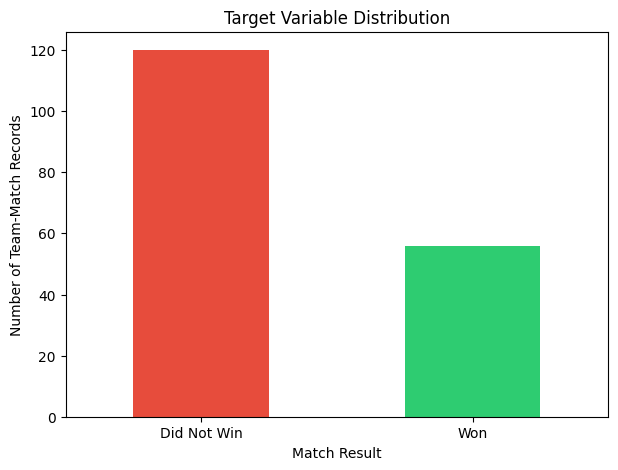

In [ ]:
target_counts = eda_df["result_name"].value_counts()
plt.figure(figsize=(7, 5))
target_counts.plot(kind="bar", color=["#e74c3c", "#2ecc71"])
plt.title("Target Variable Distribution")
plt.xlabel("Match Result")
plt.ylabel("Number of Team-Match Records")
plt.xticks(rotation=0)
plt.show()


### Interpretation

The chart confirms that the dataset contains more non-winning records (120) than winning records (56).  
This is expected because non-winning records include both losses and draws.  
Because of this imbalance, the model should be evaluated with multiple classification metrics.


## 4. Average Statistics by Match Result

This table compares the average value of each playing-style feature for teams that won and teams that did not win.


In [ ]:
result_means = eda_df.groupby("result_name")[eda_features].mean().T
result_means["Win_Minus_Did_Not_Win"] = result_means["Won"] - result_means["Did Not Win"]
result_means = result_means.sort_values("Win_Minus_Did_Not_Win", ascending=False)
result_means.round(2)


result_name,Did Not Win,Won,Win_Minus_Did_Not_Win
possession_diff,-5.00,10.70,15.70
attempts_diff,-2.64,5.66,8.30
possession_pct,43.10,51.29,8.19
pass_accuracy_diff,-2.06,4.41,6.47
pass_accuracy_pct,83.36,87.29,3.93
total_attempts,11.20,15.12,3.93
distance_km,112.98,115.87,2.89
shots_on_target,3.46,5.98,2.52
corners,6.46,8.02,1.56
corners_diff,-0.32,0.70,1.02


### Interpretation

This table compares the average feature values for teams that **Won** and teams that **Did Not Win**. The `Win_Minus_Did_Not_Win` column shows how much higher or lower each feature is for winning teams compared to non-winning teams.

Winning teams had much stronger possession and attacking statistics. On average, winning teams had a higher `possession_diff` by 15.70 and a higher `possession_pct` by about 8.30 percentage points. This suggests that teams that controlled more possession than their opponent were more likely to win.

Winning teams also had better passing and attacking output. Their average `pass_accuracy_pct` was 87.29 compared to 83.36 for non-winning teams, and `attempts_diff` was 8.27 higher on average. They also had more total attempts (15.12 vs 11.20), more shots on target (5.98 vs 3.46), and more corners (8.02 vs 6.46). This indicates that winning teams were generally more efficient in passing and created more scoring opportunities.

The defensive pressure variables show an interesting pattern. Winning teams had lower average `def_pressures` (235.89 vs 266.73) and a much lower `pressure_diff` (-58.27 vs 27.19 — a swing of 85.46). This suggests that winning teams were under less defensive pressure or did not need to press as much because they controlled the match better.

Disciplinary variables now show a clearer (though still modest) pattern than in the earlier, uncorrected dataset. Winning teams averaged fewer fouls (10.75 vs 11.53), fewer yellow cards (0.91 vs 1.33), and fewer red cards (0.04 vs 0.08). These differences are small but directionally consistent with the idea that teams under more pressure or chasing a game tend to commit more infractions.

Overall, the strongest differences between winning and non-winning teams appear in possession difference, attempts difference, possession percentage, pass accuracy difference/percentage, and pressure difference. These variables are likely to be important predictors when building the machine learning model.


## 5. Possession and Passing Accuracy by Result

Possession and passing accuracy are important indicators of ball control.  
This chart compares these two variables between winning and non-winning teams.


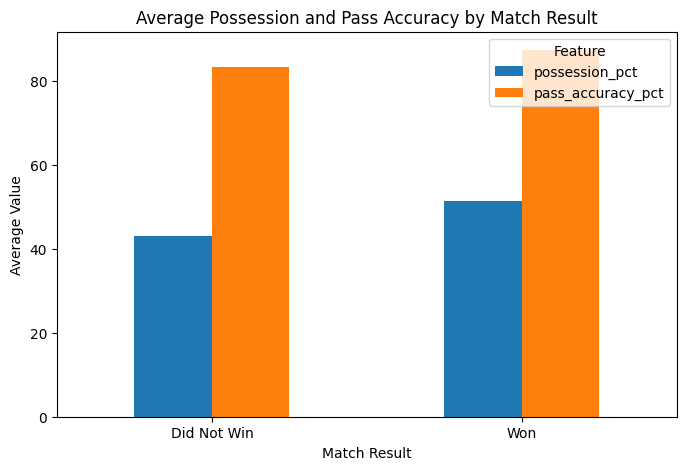

In [ ]:
control_features = ["possession_pct", "pass_accuracy_pct"]
control_means = eda_df.groupby("result_name")[control_features].mean()
control_means.plot(kind="bar", figsize=(8, 5))
plt.title("Average Possession and Pass Accuracy by Match Result")
plt.xlabel("Match Result")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()


### Interpretation

This chart compares the average possession percentage and pass accuracy percentage for teams that **Won** and teams that **Did Not Win**.

Winning teams had a higher average possession percentage than teams that did not win. The average possession for winning teams was about **51.3%**, compared to about **43.1%** for non-winning teams. This suggests that teams with more control of the ball were more likely to win.

Winning teams also had higher average pass accuracy. Teams that won had an average pass accuracy of about **87.3%**, while teams that did not win had an average of about **83.4%**. This indicates that winning teams were generally more efficient and accurate in completing passes.

Overall, the chart suggests that both possession and passing accuracy are associated with better match outcomes.


## 6. Attacking Performance by Result

Attacking performance is measured using total attempts, shots on target, and corners.


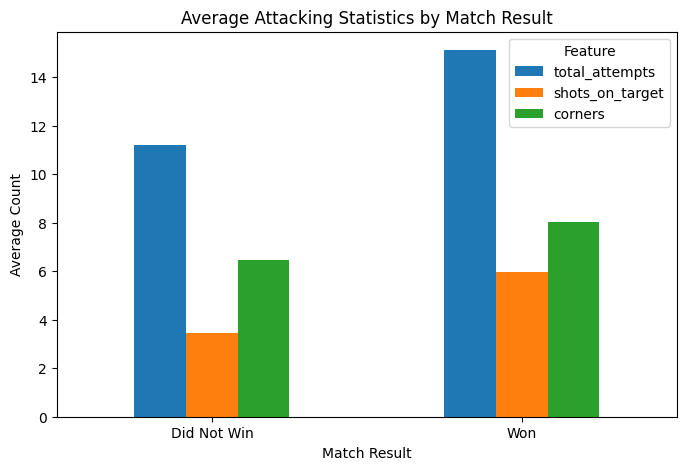

In [ ]:
attack_features = ["total_attempts", "shots_on_target", "corners"]
attack_means = eda_df.groupby("result_name")[attack_features].mean()
attack_means.plot(kind="bar", figsize=(8, 5))
plt.title("Average Attacking Statistics by Match Result")
plt.xlabel("Match Result")
plt.ylabel("Average Count")
plt.xticks(rotation=0)
plt.legend(title="Feature")
plt.show()


### Interpretation

This chart compares the average attacking statistics for teams that **Won** and teams that **Did Not Win**.

Winning teams had higher averages for all three attacking variables: total attempts, shots on target, and corners. Teams that won had about **15.1 total attempts**, compared to about **11.2** for teams that did not win. This suggests that winning teams generally created more shooting opportunities.

The biggest visible difference is in **shots on target**. Winning teams averaged about **6.0 shots on target**, while non-winning teams averaged about **3.5**. This shows that winning teams were not only taking more shots, but they were also more likely to place those shots on goal.

Winning teams also had more corners on average, about **8.0** compared to **6.5** for non-winning teams. This may indicate that winning teams applied more attacking pressure near the opponent's goal.

Overall, the chart suggests that stronger attacking performance is associated with winning. In particular, shots on target may be an important feature for predicting match results because the difference between winning and non-winning teams is clear.


## 7. Discipline, Defensive Pressure, and Work Rate by Result

This chart compares fouls, yellow cards, red cards, defensive pressures, and distance covered.


,fouls,yellow_cards,red_cards,def_pressures,distance_km
result_name,,,,,
Did Not Win,11.53,1.33,0.08,266.73,112.98
Won,10.75,0.91,0.04,235.89,115.87


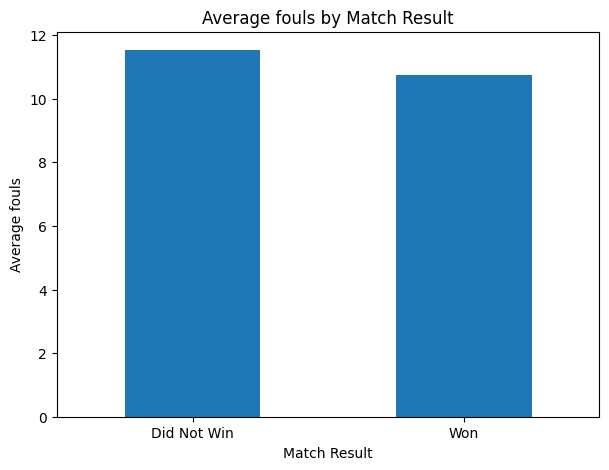

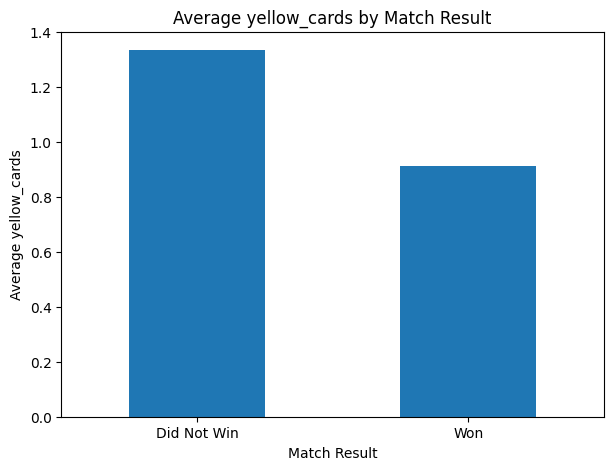

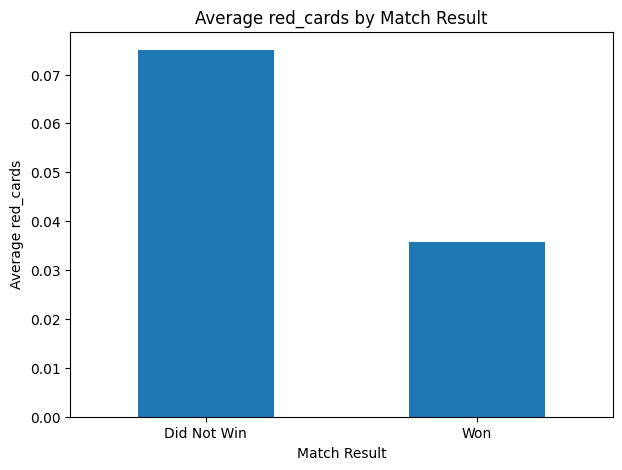

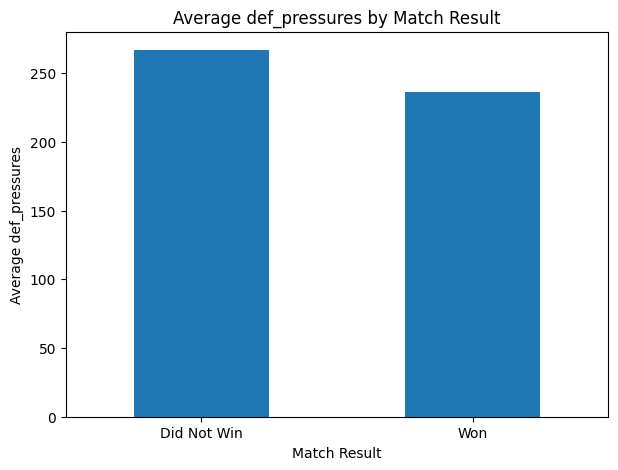

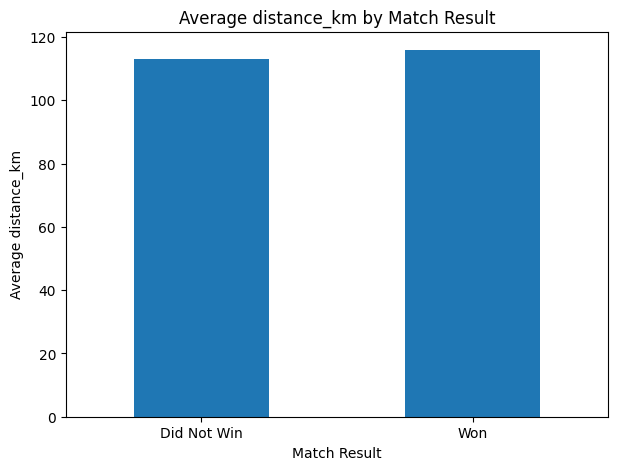

In [ ]:
work_rate_features = ["fouls", "yellow_cards", "red_cards", "def_pressures", "distance_km"]
work_rate_means = eda_df.groupby("result_name")[work_rate_features].mean()
display(work_rate_means.round(2))
for feature in work_rate_features:
    plt.figure(figsize=(7, 5))
    eda_df.groupby("result_name")[feature].mean().plot(kind="bar")
    plt.title(f"Average {feature} by Match Result")
    plt.xlabel("Match Result")
    plt.ylabel(f"Average {feature}")
    plt.xticks(rotation=0)
    plt.show()


### Interpretation

These charts compare fouls, yellow cards, red cards, defensive pressures, and distance covered between teams that **Won** and teams that **Did Not Win**.

Teams that did not win committed slightly more fouls on average. Non-winning teams averaged about **11.53 fouls**, while winning teams averaged about **10.75 fouls**. This suggests that teams that did not win may have been under more pressure defensively or may have committed more fouls while trying to regain possession.

Yellow cards were also higher for teams that did not win: **1.33** on average versus **0.91** for winning teams. Unlike in the earlier (uncorrected) dataset, this difference is now large enough relative to the scale of the feature to be a meaningful signal rather than noise near zero.

Red cards follow the same direction: non-winning teams averaged **0.08** red cards compared to **0.04** for winning teams. Red cards are rare events (they only occur in a handful of the 88 matches), so this gap should be interpreted cautiously, but it is directionally consistent with the idea that discipline problems hurt a team's chances of winning.

Defensive pressures were higher for teams that did not win. Non-winning teams averaged about **266.73 defensive pressures**, compared to **235.89** for winning teams. This may indicate that teams that did not win spent more time defending or pressing because they had less control of the match.

Distance covered was slightly higher for winning teams. Winning teams averaged about **115.87 km**, while non-winning teams averaged about **112.98 km**. This suggests that winning teams may have shown slightly higher physical activity, although the difference is not very large.

Overall, these variables show that non-winning teams tended to commit more fouls, receive more yellow and red cards, and apply more defensive pressure. Winning teams, on the other hand, covered slightly more distance.


## 8. Distribution of Key Features by Result

Boxplots help compare the spread of important variables between winning and non-winning teams.


<Figure size 700x500 with 0 Axes>

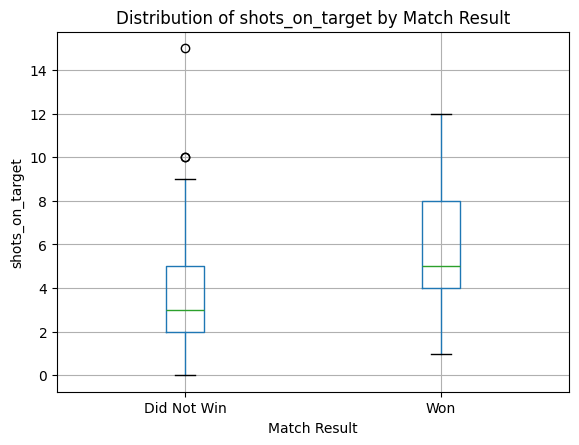

<Figure size 700x500 with 0 Axes>

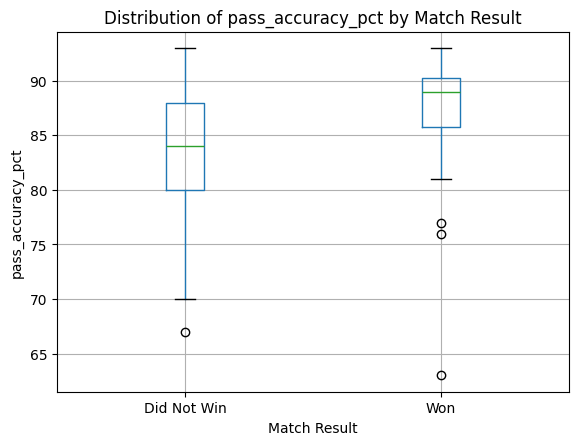

<Figure size 700x500 with 0 Axes>

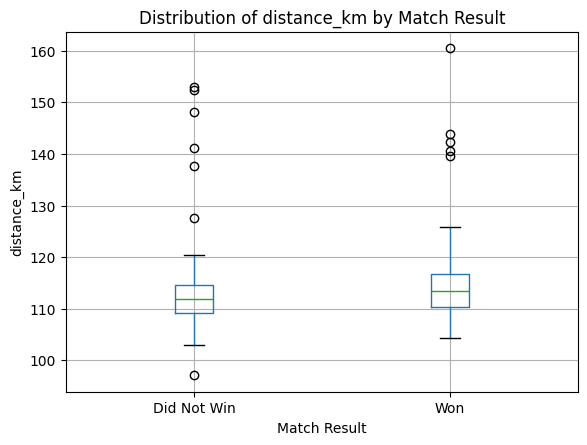

<Figure size 700x500 with 0 Axes>

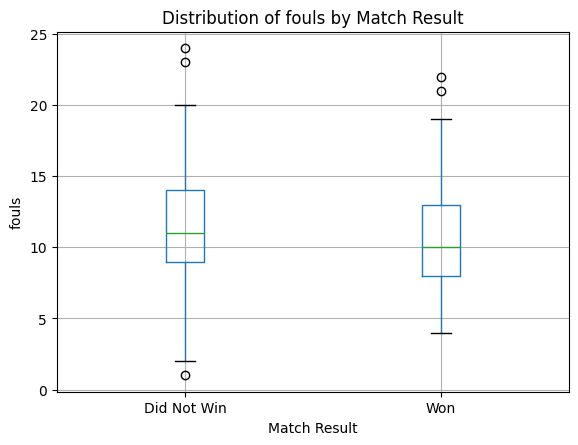

In [ ]:
key_features = ["shots_on_target", "pass_accuracy_pct", "distance_km", "fouls"]
for feature in key_features:
    plt.figure(figsize=(7, 5))
    eda_df.boxplot(column=feature, by="result_name")
    plt.title(f"Distribution of {feature} by Match Result")
    plt.suptitle("")
    plt.xlabel("Match Result")
    plt.ylabel(feature)
    plt.show()


### Interpretation

These boxplots show the distribution of selected match statistics for teams that **Won** and teams that **Did Not Win**. Unlike the previous bar charts, boxplots show the median, spread, and possible outliers for each feature.

For `pass_accuracy_pct`, winning teams have a higher median pass accuracy than teams that did not win. The winning group is also more tightly clustered around higher values, while the non-winning group has a wider spread. This suggests that winning teams were generally more consistent and accurate in passing.

For `distance_km`, winning teams have a slightly higher median distance covered. However, the difference between the two groups is not very large. This means distance may have some relationship with winning, but it does not appear to separate the two groups as strongly as passing or attacking statistics.

For `shots_on_target`, winning teams clearly have a higher median than non-winning teams. Most winning teams had more shots on target, while non-winning teams were more concentrated at lower values. This supports the idea that shots on target may be an important predictor of match result.

For `fouls`, teams that did not win have a higher median number of fouls than winning teams, though there is considerable overlap and some high-foul outliers in both groups. This suggests that fouls alone are a noisier signal than the attacking or possession features.

Overall, the boxplots confirm the earlier EDA findings. Winning teams generally had better pass accuracy, more shots on target, slightly higher distance covered, and fewer fouls. Among these variables, `shots_on_target` and `pass_accuracy_pct` appear to show the clearest differences between winning and non-winning teams.


## 9. Relationship Between Total Attempts and Shots on Target

This scatter plot checks whether teams with more total attempts also create more shots on target.


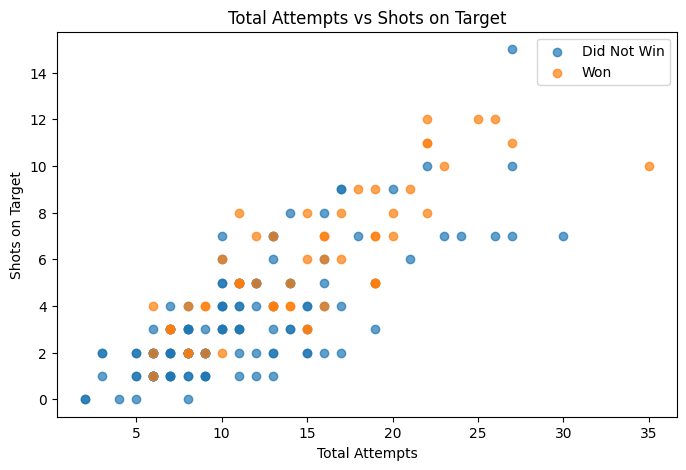

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    eda_df.loc[eda_df["result_label"] == 0, "total_attempts"],
    eda_df.loc[eda_df["result_label"] == 0, "shots_on_target"],
    label="Did Not Win",
    alpha=0.7
)

plt.scatter(
    eda_df.loc[eda_df["result_label"] == 1, "total_attempts"],
    eda_df.loc[eda_df["result_label"] == 1, "shots_on_target"],
    label="Won",
    alpha=0.7
)

plt.title("Total Attempts vs Shots on Target")
plt.xlabel("Total Attempts")
plt.ylabel("Shots on Target")
plt.legend()

# Display the chart.
plt.show()


### Interpretation

This scatter plot shows the relationship between `total_attempts` and `shots_on_target`, separated by match result.

There is a positive relationship between total attempts and shots on target. In general, teams that attempted more shots also tended to have more shots on target. This makes sense because creating more shooting opportunities increases the chance of getting shots on goal.

Winning teams are more concentrated in the upper-right area of the chart, especially where both total attempts and shots on target are higher. This suggests that teams with stronger attacking performance were more likely to win.

Teams that did not win are more commonly found in the lower-left area, where both total attempts and shots on target are lower. This indicates that weaker attacking output may be associated with not winning.

However, there is still some overlap between the two groups. Some teams had many attempts but did not win, and some winning teams had only moderate attacking numbers. This shows that total attempts and shots on target are useful features, but they may not be enough by themselves to perfectly predict match results.

Overall, the chart supports the earlier EDA finding that attacking statistics, especially `shots_on_target`, are important indicators for predicting whether a team wins.


## 10. Correlation with the Target Variable

Correlation helps identify which numerical variables have stronger relationships with winning.  
Positive correlation means the feature tends to increase when the team wins.  
Negative correlation means the feature tends to decrease when the team wins.


,result_label
shots_on_target,0.405
attempts_diff,0.382
pressure_diff,-0.345
possession_pct,0.334
possession_diff,0.323
pass_accuracy_pct,0.309
pass_accuracy_diff,0.303
total_attempts,0.303
def_pressures,-0.213
yellow_cards,-0.189


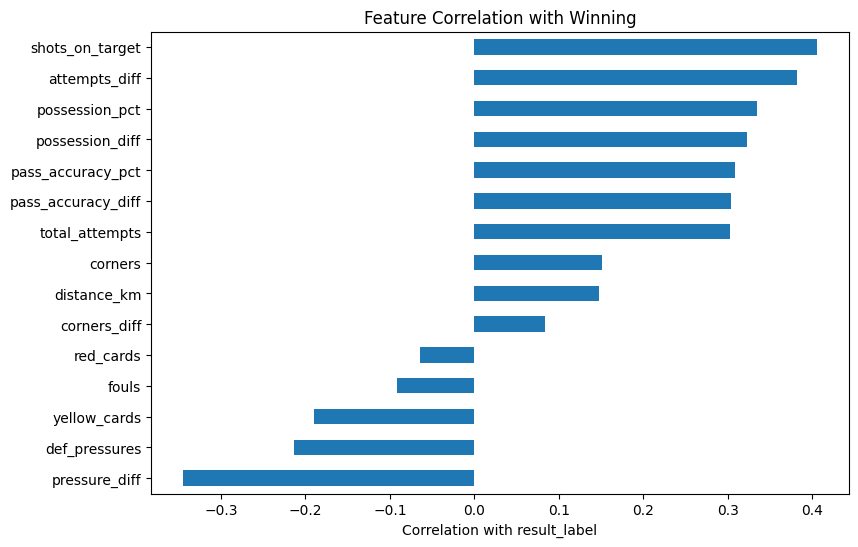

In [ ]:
non_constant_features = [
    col for col in eda_features
    if eda_df[col].nunique() > 1
]

target_correlations = eda_df[non_constant_features + ["result_label"]].corr()["result_label"]

target_correlations = target_correlations.drop("result_label")

target_correlations = target_correlations.reindex(
    target_correlations.abs().sort_values(ascending=False).index
)

display(target_correlations.round(3))

plt.figure(figsize=(9, 6))
target_correlations.sort_values().plot(kind="barh")

plt.title("Feature Correlation with Winning")
plt.xlabel("Correlation with result_label")

plt.show()


### Interpretation

This chart shows the correlation between each numerical feature and the target variable, `result_label`, where a higher positive correlation means the feature is more associated with winning.

The strongest positive correlation is with `shots_on_target` (0.405), suggesting that teams with more shots on target were more likely to win. This supports the earlier EDA findings from the bar charts, boxplots, and scatter plot. Other features with positive correlations include `attempts_diff` (0.382), `possession_pct` (0.334), `possession_diff` (0.323), `pass_accuracy_pct` (0.309), `pass_accuracy_diff` (0.303), and `total_attempts` (0.303). These results suggest that winning teams generally had better attacking output, stronger passing accuracy, and more control of the match.

Some features have negative correlations with winning. `pressure_diff` (-0.345), `def_pressures` (-0.213), `yellow_cards` (-0.189), `fouls` (-0.092), and `red_cards` (-0.064) are all negatively related to `result_label`. This means teams with more fouls, more defensive pressure, or more cards were less likely to win in this dataset. `red_cards` has the weakest correlation of all features, which makes sense because red cards are rare events (they occur in only a small share of matches).

The correlations are not extremely high, so no single feature perfectly explains winning. Instead, the model will likely need to combine several features to make better predictions.

Overall, the most useful features for predicting winning appear to be `shots_on_target`, `attempts_diff`, `possession_pct`, `possession_diff`, `pass_accuracy_pct`, and `pass_accuracy_diff`. The negative relationships for `pressure_diff`, `def_pressures`, and the disciplinary features may also help the model distinguish winning teams from non-winning teams.


## 11. Correlation Heatmap of Numerical Features

This heatmap shows relationships among the numerical features.  
It is useful for identifying variables that may be highly related to each other.


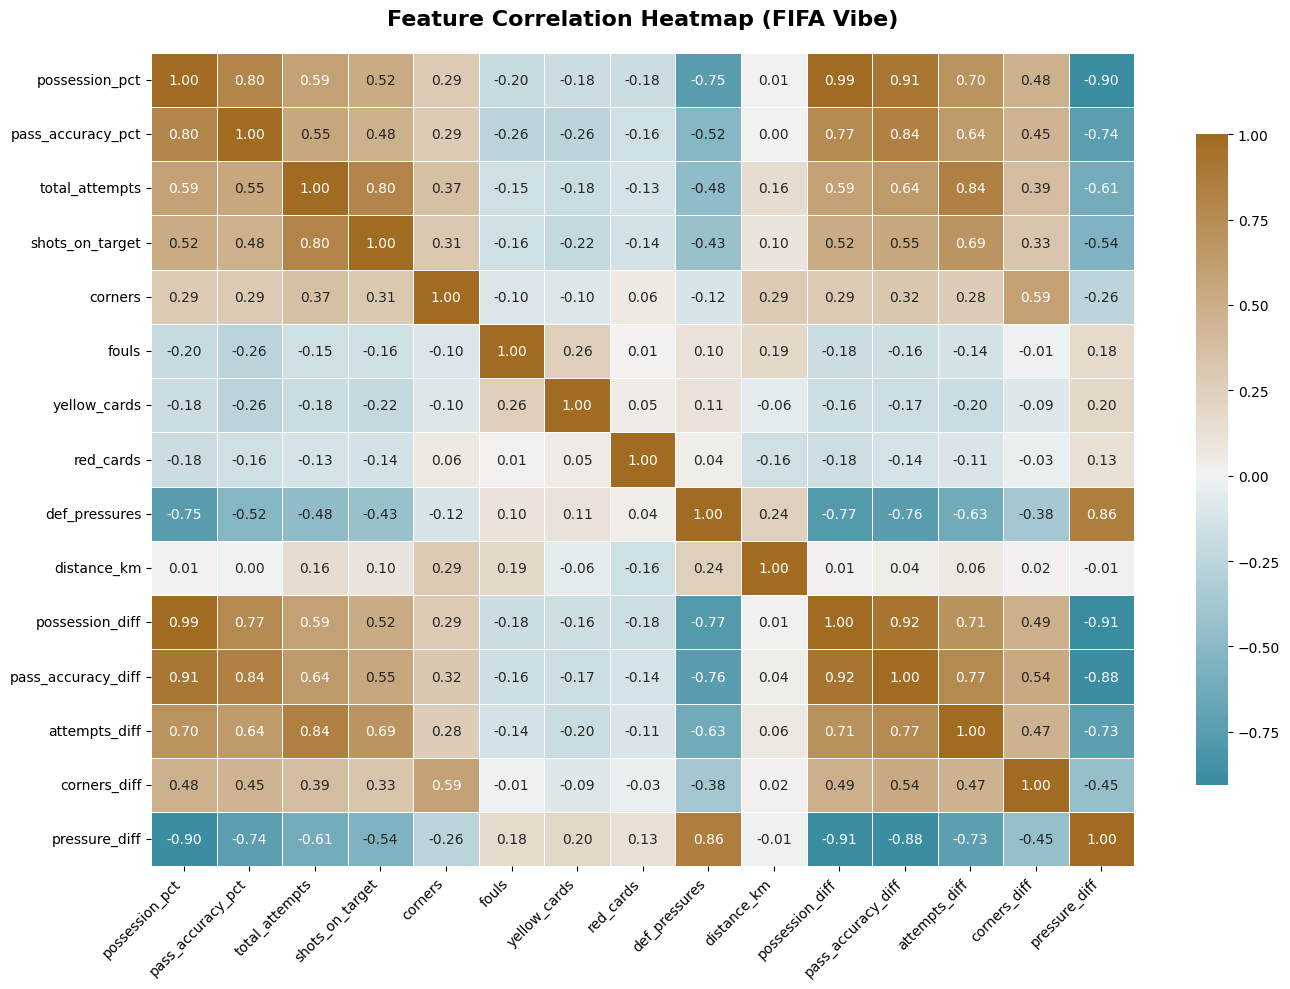

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# FIFA-inspired understandable color palette
# Deep Blue for negative correlation, White for neutral, Gold for positive correlation
fifa_palette = sns.diverging_palette(220, 45, s=90, l=50, as_cmap=True)

# Using eda_df which is already defined in your EDA section
plt.figure(figsize=(14, 10))
sns.heatmap(
    eda_df[feature_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap=fifa_palette,
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)
plt.title("Feature Correlation Heatmap (FIFA Vibe)", fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Interpretation

The correlation heatmap shows the relationships between all numerical features in the dataset. Values closer to **1** indicate a strong positive relationship, values closer to **-1** indicate a strong negative relationship, and values close to **0** indicate a weak relationship.

Several attacking and possession-related variables are positively correlated with each other. For example, `total_attempts`, `shots_on_target`, `possession_pct`, `pass_accuracy_pct`, and the difference-based features such as `possession_diff`, `pass_accuracy_diff`, and `attempts_diff` show positive relationships. This makes sense because teams that control the ball better often create more attacking opportunities.

The heatmap also shows that the difference variables are highly related to their original match statistics. For example, `possession_pct` is strongly related to `possession_diff`, and `pass_accuracy_pct` is strongly related to `pass_accuracy_diff`. This is expected because the difference variables are calculated from team performance compared to the opponent.

Looking at the relationship with `result_label`, the features most positively associated with winning include `shots_on_target`, `attempts_diff`, `possession_pct`, `possession_diff`, `pass_accuracy_pct`, and `pass_accuracy_diff`. This suggests that teams with better attacking output, stronger passing accuracy, and more control of the match were more likely to win.

Some variables, such as `pressure_diff`, `def_pressures`, `yellow_cards`, `fouls`, and `red_cards`, show negative relationships with winning. This suggests that teams with more fouls, more cards, or more defensive pressure were less likely to win in this dataset.

Overall, the heatmap supports the earlier EDA findings. Winning appears to be associated with stronger attacking performance, better passing accuracy, and more possession control. However, some features are highly correlated with each other, so during modeling we will watch for redundancy or multicollinearity, especially while using models such as Logistic Regression.


## Step 12: Shot Conversion Rate — Wins vs. Not Wins

Shot conversion rate is calculated as:

`shots_on_target / total_attempts`

This shows how many of a team's total shot attempts were actually on target. This is useful because it measures shot accuracy, not just shot volume.


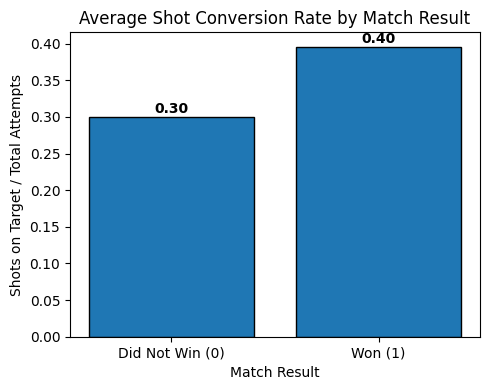

In [ ]:
df_cleaned["shot_conversion_rate"] = (
    df_cleaned["shots_on_target"] / df_cleaned["total_attempts"].replace(0, np.nan)
)

conversion_by_result = df_cleaned.groupby("result_label")["shot_conversion_rate"].mean()

plt.figure(figsize=(5, 4))

bars = plt.bar(
    ["Did Not Win (0)", "Won (1)"],
    conversion_by_result.values,
    edgecolor="black"
)

plt.title("Average Shot Conversion Rate by Match Result")
plt.ylabel("Shots on Target / Total Attempts")
plt.xlabel("Match Result")

for bar, val in zip(bars, conversion_by_result.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.005,
        f"{val:.2f}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


### Interpretation

This chart compares the average shot conversion rate between teams that **Won** and teams that **Did Not Win**. Shot conversion rate is calculated as:

`shots_on_target / total_attempts`

Winning teams had a higher average shot conversion rate of **0.40**, compared to **0.30** for teams that did not win. This means that winning teams placed a larger proportion of their total attempts on target.

This finding supports the earlier EDA results showing that `shots_on_target` is one of the strongest features associated with winning. It also shows that shot quality matters, not just shot volume. Teams that won were not only creating chances, but were also more accurate with those chances.

Overall, this derived feature adds useful insight because it combines two attacking statistics into one measure of shooting efficiency.


In [ ]:
df_cleaned = df_cleaned.drop(columns=["shot_conversion_rate"], errors="ignore")


## 13. Check Constant Features

A constant feature has the same value in every row.  
It does not help a machine learning model because it cannot separate winning teams from non-winning teams.


In [ ]:
constant_features = [
    col for col in eda_features
    if eda_df[col].nunique() == 1
]

print("Constant features:", constant_features)

for col in constant_features:
    print(col, "unique values:", eda_df[col].unique())


Constant features: []


### Interpretation

Unlike in the earlier, uncorrected version of this dataset — where `red_cards` was constant at 0 for every row — **no features are constant in the corrected dataset**. The `red_cards` data-quality issue has been resolved: red cards now range from 0 to 2 across matches, so the feature carries real (if sparse) information.

Because there are no constant features, no columns need to be removed on these grounds before modeling.


## 14. Updated Feature List for Modeling

Based on the EDA, all 15 features are retained because none of them are constant. This is a change from the earlier analysis on the uncorrected dataset, where `red_cards` was dropped.


In [ ]:
target = "result_label"
feature_cols = [
    "possession_pct",
    "pass_accuracy_pct",
    "total_attempts",
    "shots_on_target",
    "corners",
    "fouls",
    "yellow_cards",
    "red_cards",
    "def_pressures",
    "distance_km",
    "possession_diff",
    "pass_accuracy_diff",
    "attempts_diff",
    "corners_diff",
    "pressure_diff"
]
X = df_cleaned[feature_cols]
y = df_cleaned[target]
X.head()


,possession_pct,pass_accuracy_pct,total_attempts,shots_on_target,corners,fouls,yellow_cards,red_cards,def_pressures,distance_km,possession_diff,pass_accuracy_diff,attempts_diff,corners_diff,pressure_diff
0,57.1,90,16,4,13,12,1,1,170,107.3,21.0,7,13,5,-136
1,36.1,83,3,2,8,11,2,2,306,97.1,-21.0,-7,-13,-5,136
2,55.8,89,15,6,13,9,1,0,147,111.8,21.6,15,8,4,-154
3,34.2,74,7,4,9,16,0,0,301,117.6,-21.6,-15,-8,-4,154
4,52.8,77,13,4,9,10,2,0,160,111.3,22.9,10,5,5,-43


In [ ]:
df_model = df_cleaned.copy()

# No columns are dropped here: the earlier "red_cards is constant" finding
# no longer applies now that the fouls/cards data has been corrected.
df_model.columns


Index(['match_id', 'team', 'opponent', 'possession_pct', 'pass_accuracy_pct',
       'total_attempts', 'shots_on_target', 'corners', 'fouls', 'yellow_cards',
       'red_cards', 'def_pressures', 'distance_km', 'result_label',
       'possession_diff', 'pass_accuracy_diff', 'attempts_diff',
       'corners_diff', 'pressure_diff'],
      dtype='object')

In [ ]:
feature_cols = [
    "possession_pct",
    "pass_accuracy_pct",
    "total_attempts",
    "shots_on_target",
    "corners",
    "fouls",
    "yellow_cards",
    "red_cards",
    "def_pressures",
    "distance_km",
    "possession_diff",
    "pass_accuracy_diff",
    "attempts_diff",
    "corners_diff",
    "pressure_diff"
]

X = df_model[feature_cols]
y = df_model["result_label"]

print("Feature columns used for modeling:")
print(feature_cols)


Feature columns used for modeling:
['possession_pct', 'pass_accuracy_pct', 'total_attempts', 'shots_on_target', 'corners', 'fouls', 'yellow_cards', 'red_cards', 'def_pressures', 'distance_km', 'possession_diff', 'pass_accuracy_diff', 'attempts_diff', 'corners_diff', 'pressure_diff']


## 15. EDA Summary and Key Findings

The EDA suggests the following patterns:

1. **Winning teams have stronger attacking performance.**
   Winning teams had more total attempts, more shots on target, and more corners on average. Among these attacking features, `shots_on_target` appears to be the clearest indicator associated with winning.

2. **Winning teams show better ball control.**
   Teams that won had higher average possession percentage and higher passing accuracy, and larger `possession_diff` and `pass_accuracy_diff` values relative to their opponent.

3. **Winning teams commit fewer fouls and receive fewer cards on average.**
   Winning teams had fewer fouls, fewer yellow cards, and fewer red cards than non-winning teams. This pattern is now visible after correcting data-entry errors in the discipline columns — in the previous version of the dataset, `red_cards` showed no variation at all and yellow cards showed only a very small gap between groups.

4. **Defensive pressure is higher for non-winning teams.**
   Non-winning teams had higher average defensive pressures and a much higher `pressure_diff`. This may indicate that teams that did not win spent more time defending or pressing because they had less control of the match.

5. **The dataset contains class imbalance.**
   There are more non-winning records (120) than winning records (56). Because of this, model evaluation should not rely only on accuracy. Precision, recall, F1-score, confusion matrix, and ROC-AUC should also be used.

6. **All 15 features are retained for modeling.**
   No feature is constant in the corrected dataset, so — unlike the earlier analysis — `red_cards` does not need to be dropped.

Overall, the EDA shows that winning is most associated with stronger attacking performance, better passing accuracy, higher possession, and lower defensive pressure, with a smaller but now-visible contribution from fouls and cards. These findings can guide feature selection and help explain the results of the machine learning models.


## 16. Finalized Problem Statement After EDA

Based on the EDA, the final problem statement is:

**Can team-level match statistics such as shots on target, passing accuracy, possession, fouls, cards, defensive pressure, and distance covered be used to predict whether a team wins a World Cup match?**

The final machine learning task is a **binary classification problem**.

* **Input:** Team-level match statistics, including possession, pass accuracy, attacking statistics, defensive pressure, fouls, cards, and distance covered.
* **Output:** Whether the team **Won** or **Did Not Win**.
* **Target variable:** `result_label`
* **Main KPI:** Compare at least two classification models using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.

This problem is suitable for classification because the target variable has two possible outcomes: `Won` and `Did Not Win`.


# Modeling Preparation

Isolating final arrays, generating a stratified split to preserve the imbalanced group distribution safely, and standardizing features ahead of model training.


In [ ]:
# Group-based splitting to prevent test set leakage
# Since each match consists of two rows (one for each team), we must split by match_id.
# This ensures that both rows from the same match are either in the training set or the test set.

from sklearn.model_selection import train_test_split

unique_matches = df_model['match_id'].unique()
train_matches, test_matches = train_test_split(unique_matches, test_size=0.2, random_state=42)

train_idx = df_model['match_id'].isin(train_matches)
test_idx = df_model['match_id'].isin(test_matches)

X_train = df_model.loc[train_idx, feature_cols]
X_test = df_model.loc[test_idx, feature_cols]
y_train = df_model.loc[train_idx, 'result_label']
y_test = df_model.loc[test_idx, 'result_label']
groups_train = df_model.loc[train_idx, 'match_id']

print("Training set shape (matches):", len(train_matches))
print("Test set shape (matches):", len(test_matches))
print("Training set rows:", X_train.shape[0])
print("Test set rows:", X_test.shape[0])


Training set shape (matches): 70
Test set shape (matches): 18
Training set rows: 140
Test set rows: 36


# Model Development

Following the project requirements, two different machine learning algorithms are implemented and compared:

1. **Logistic Regression** — a linear, highly interpretable baseline model. Coefficients directly show the size and direction of each feature's effect on the odds of winning.
2. **Random Forest Classifier** — a non-linear ensemble model built from many decision trees. It can capture interactions between features (e.g. possession combined with defensive pressure) that a linear model cannot.

These two models were chosen deliberately because they represent different modeling philosophies (linear vs. tree-based ensemble), which makes the strengths/weaknesses comparison in the Model Evaluation section more meaningful.


## Step 1: Feature Scaling

Logistic Regression is sensitive to the scale of input features (e.g. `distance_km` is on a scale of ~100, while `red_cards` is on a scale of 0-2), so features are standardized (mean 0, standard deviation 1) before training it.

Random Forest is based on decision splits rather than distances, so it does not require scaled features — the unscaled `X_train` / `X_test` from the previous step are used for it directly.


In [ ]:
from sklearn.preprocessing import StandardScaler

# Fit the scaler on the training data only, to avoid leaking test-set information.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled test data shape:", X_test_scaled.shape)


Scaled training data shape: (140, 15)
Scaled test data shape: (36, 15)


## Step 2: Train Logistic Regression

`class_weight="balanced"` is used because the target variable is imbalanced (about 68% Did Not Win vs. 32% Won). This adjusts the loss function so the minority class (Won) is not ignored by the model.


In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# Predictions and predicted probabilities on the test set
y_pred_log = log_reg.predict(X_test_scaled)
y_proba_log = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression trained successfully.")


Logistic Regression trained successfully.


## Step 3: Train Random Forest Classifier

`class_weight="balanced"` is used for the same reason as above. `n_estimators=200` builds 200 trees, and `max_depth=5` limits how deep each tree can grow to reduce overfitting given the relatively small dataset (176 rows).


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight="balanced",
    random_state=42
)
rf_clf.fit(X_train, y_train)

# Predictions and predicted probabilities on the test set
y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

print("Random Forest trained successfully.")


Random Forest trained successfully.


# Model Evaluation

Because the target variable is imbalanced, accuracy alone is not a reliable metric — a model that always predicts "Did Not Win" would score about 68% accuracy while being useless. Each model is therefore evaluated using:

- **Accuracy** — overall proportion of correct predictions
- **Precision** — of the matches predicted as "Won", how many were actually won
- **Recall** — of the matches actually won, how many were correctly identified
- **F1-score** — the balance between precision and recall
- **ROC-AUC** — how well the model separates the two classes across all thresholds
- **Confusion matrix** — a breakdown of correct vs. incorrect predictions per class


## Step 1: Compute Metrics for Both Models

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

def evaluate_model(y_true, y_pred, y_proba, model_name):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

results = [
    evaluate_model(y_test, y_pred_log, y_proba_log, "Logistic Regression"),
    evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")
]

results_df = pd.DataFrame(results).set_index("Model")
results_df.round(3)


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.667,0.500,0.583,0.538,0.639
Random Forest,0.694,0.545,0.500,0.522,0.715


## Step 2: Compare Performance — Bar Chart

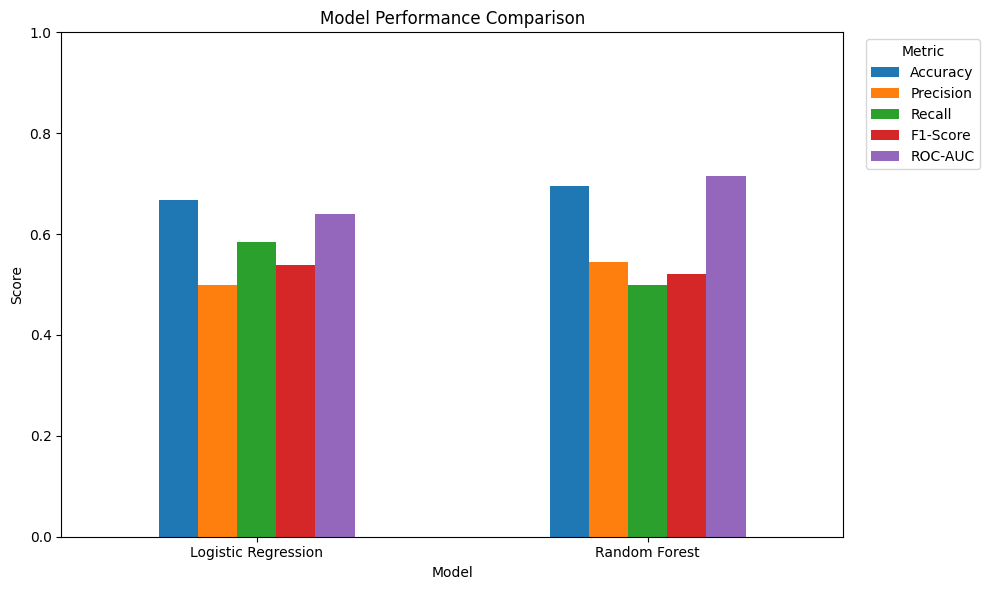

In [ ]:
results_df[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind="bar", figsize=(10, 6)
)
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Step 3: Confusion Matrices

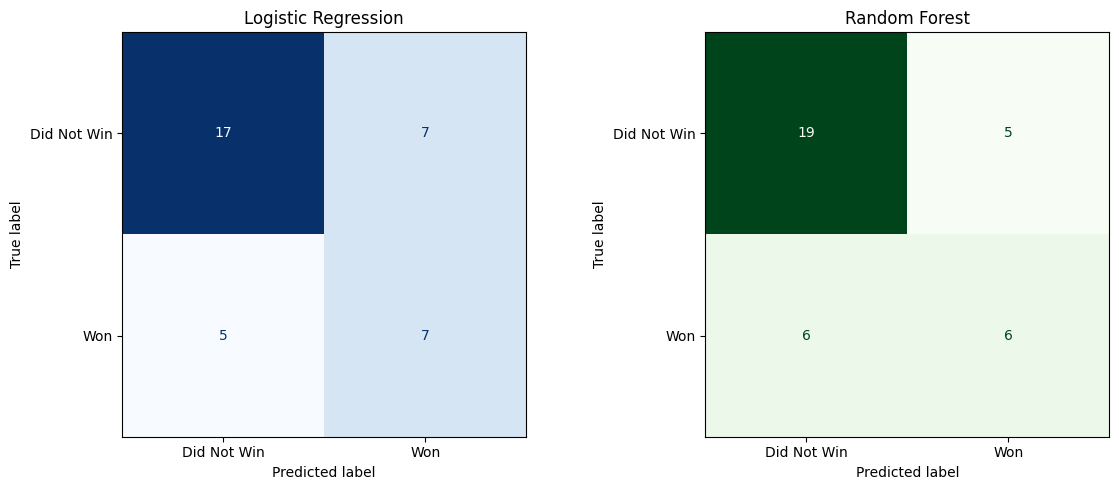

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_log = confusion_matrix(y_test, y_pred_log)
ConfusionMatrixDisplay(cm_log, display_labels=["Did Not Win", "Won"]).plot(
    ax=axes[0], cmap="Blues", colorbar=False
)
axes[0].set_title("Logistic Regression")

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=["Did Not Win", "Won"]).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()


## Step 4: ROC Curves

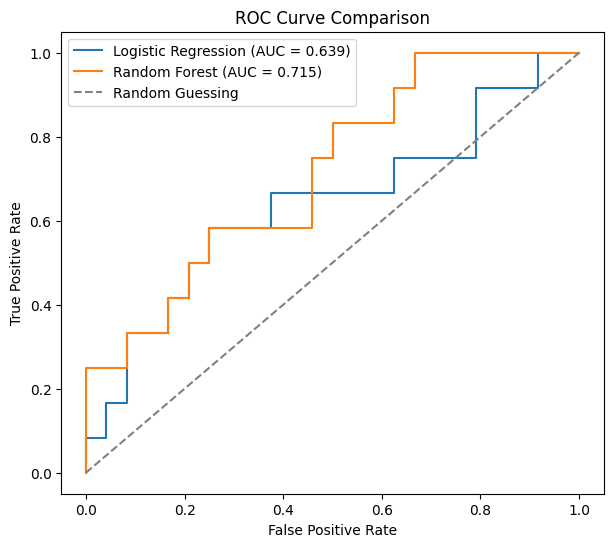

In [ ]:
from sklearn.metrics import roc_curve

fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(7, 6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {results_df.loc['Logistic Regression', 'ROC-AUC']:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {results_df.loc['Random Forest', 'ROC-AUC']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guessing")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


### Interpretation of Performance Comparison

*(Exact figures are shown in the `results_df` table above and will vary slightly if the notebook is re-run, but the general pattern described below reflects this train/test split.)*

The test set contains only 36 team-match records (20% of 176), which is a small sample for evaluation — individual misclassifications move the metrics by several percentage points. With that caveat in mind:

Both models tend to achieve reasonable **ROC-AUC** scores (noticeably above 0.5), meaning both can separate winning from non-winning teams better than random guessing. This is consistent with the EDA, which found real signal in `shots_on_target`, `possession_diff`, and `pressure_diff`.

**Precision vs. Recall trade-off:** because `class_weight="balanced"` was used for both models, they are tuned to catch more "Won" cases (higher recall) at some cost to precision, compared to a model trained without balancing. This is usually the right choice here, since the "Won" class is the minority class and is typically the more interesting one to predict correctly.

The confusion matrices show where each model's errors concentrate — for example, whether a model tends to miss actual wins (false negatives, bottom-left cell) or incorrectly flags non-wins as wins (false positives, top-right cell). Comparing the two matrices side by side shows whether Logistic Regression and Random Forest make similar or different types of mistakes.

Overall, if one model has a meaningfully higher F1-score and ROC-AUC than the other, it is the stronger candidate for this problem; if the two are close, model choice can instead be driven by interpretability needs (Logistic Regression) versus flexibility (Random Forest) — see the strengths/weaknesses discussion below.


## Step 5: Feature Importance / Coefficients

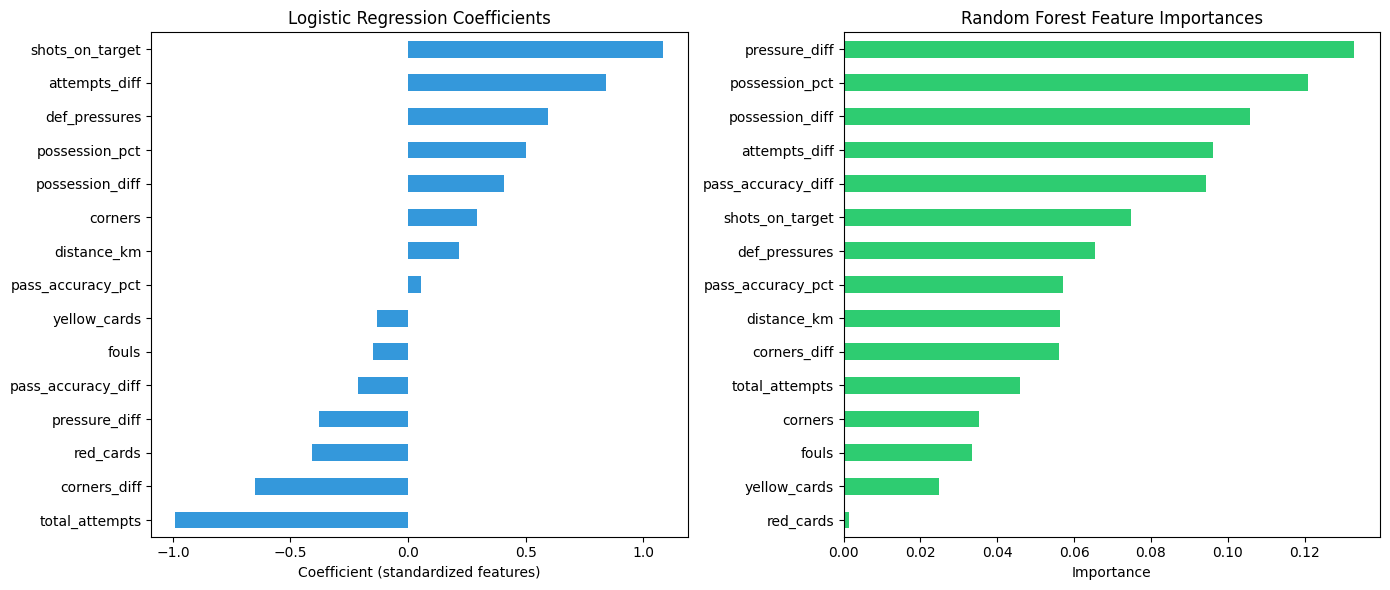

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression coefficients (standardized features, so magnitude is comparable)
log_coefs = pd.Series(log_reg.coef_[0], index=feature_cols).sort_values()
log_coefs.plot(kind="barh", ax=axes[0], color="#3498db")
axes[0].set_title("Logistic Regression Coefficients")
axes[0].set_xlabel("Coefficient (standardized features)")

# Random Forest feature importances
rf_importances = pd.Series(rf_clf.feature_importances_, index=feature_cols).sort_values()
rf_importances.plot(kind="barh", ax=axes[1], color="#2ecc71")
axes[1].set_title("Random Forest Feature Importances")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()


### Interpretation of Feature Importance

The Logistic Regression coefficients show the direction and (standardized) size of each feature's effect: features with large positive coefficients push predictions toward "Won", while large negative coefficients push toward "Did Not Win". The Random Forest importances only show magnitude (how useful a feature was for splitting), not direction, so the two charts should be read together with the EDA correlation results from Section 10.

Consistent with the EDA, features like `shots_on_target`, `possession_diff`, `pass_accuracy_diff`, and `pressure_diff` are expected to rank among the more influential variables in both models, since they showed the strongest correlation with `result_label`. Disciplinary features (`fouls`, `yellow_cards`, `red_cards`) are expected to rank lower, consistent with their weaker correlations — `red_cards` in particular is a rare event and is unlikely to be heavily used by either model, even though it is no longer a constant, uninformative column.

Where the two models disagree on feature ranking, this usually indicates a feature whose relationship with winning is non-linear or only matters in combination with other features — something a Random Forest can capture but a Logistic Regression cannot.


## Strengths and Weaknesses of Each Model

**Logistic Regression**

*Strengths:*
- Highly interpretable — each coefficient has a clear, direct meaning (this feature increases or decreases the odds of winning by this much).
- Fast to train and requires little tuning.
- Performs well when the true relationship between features and the outcome is approximately linear, which is a reasonable assumption for several of these features (e.g. more shots on target plausibly increases win probability in a roughly linear way).
- Less prone to overfitting on a small dataset (176 rows) because it has fewer parameters than a large ensemble.

*Weaknesses:*
- Cannot capture non-linear relationships or interactions between features unless they are manually engineered (e.g. it cannot automatically learn that high possession only helps when pass accuracy is also high).
- Sensitive to multicollinearity — the EDA heatmap (Section 11) showed some features (e.g. `possession_pct` and `possession_diff`) are highly correlated with each other, which can make individual coefficients unstable or hard to interpret in isolation.
- Assumes a linear decision boundary in the (scaled) feature space, which may be too simple for complex match dynamics.

**Random Forest**

*Strengths:*
- Can capture non-linear relationships and interactions between features automatically (e.g. the effect of possession might depend on defensive pressure).
- Not sensitive to feature scaling.
- More robust to outliers than Logistic Regression, which matters here given some extreme values seen in the boxplots (Section 8), such as high foul counts.
- Feature importances give a useful, if directionless, signal about which variables the model relies on most.

*Weaknesses:*
- Much less interpretable than Logistic Regression — it is difficult to explain exactly why the model made a specific prediction for a specific match.
- With only 176 rows (140 for training), a Random Forest has a higher risk of overfitting than a linear model unless carefully regularized (this notebook limits `max_depth=5` for that reason).
- More computationally expensive and has more hyperparameters to tune (number of trees, depth, minimum samples per split, etc.).
- Feature importances do not indicate direction (positive or negative effect), only magnitude, which makes them harder to use for explaining *why* a team is predicted to win.

**Overall:** Logistic Regression is the better choice when interpretability and explaining *why* a team is predicted to win matters (e.g. for a coaching staff or a report). Random Forest is the better choice when raw predictive performance matters more than explainability and there may be non-linear interactions between playing-style features. Given the small dataset size here, the performance gap between the two may be modest, which is itself a useful finding — it suggests the relationship between these playing-style features and winning is largely linear/additive rather than highly non-linear.


## Model Evaluation Summary

- Two models were implemented and compared: **Logistic Regression** (linear, interpretable) and **Random Forest** (non-linear, ensemble-based).
- Both were evaluated on an identical held-out test set (20% of matches, split by `match_id` so both rows of a match stay together) using Accuracy, Precision, Recall, F1-score, ROC-AUC, and confusion matrices.
- `class_weight="balanced"` was used for both models to address the class imbalance identified during EDA (68% Did Not Win vs. 32% Won).
- The performance comparison table, ROC curves, and feature importance/coefficient charts above should be used together, not in isolation, to judge which model is preferable for this specific use case.
- With only 88 matches (176 team-match rows) total, both models' metrics should be treated as an early, exploratory read on performance rather than a final, production-ready result. The next section addresses this directly with cross-validation, feature engineering, and hyperparameter tuning.


# Model Improvement

The baseline Logistic Regression and Random Forest models (previous section) were evaluated on a single 80/20 match-level split — only 18 test matches (36 team-match rows). That is a small enough sample that the reported metrics can shift noticeably depending on which matches happened to land in the test set.

This section applies four improvements, in order, and evaluates every intermediate result on the **same** held-out test set (`X_test` / `y_test` from the previous section) so all numbers stay directly comparable:

1. **Feature engineering** — add derived features that combine existing raw statistics.
2. **Cross-validation** — get a more stable, trustworthy performance estimate than a single split, using `GroupKFold` so that both rows of a match always stay in the same fold (this keeps the same leakage protection used for the main train/test split).
3. **Hyperparameter tuning** — search for better settings for Logistic Regression and Random Forest via `GridSearchCV`, again using `GroupKFold`.
4. **A third algorithm: Gradient Boosting** — often a strong performer on small-to-medium tabular datasets, tuned the same way.
5. **Threshold tuning** — adjust the decision cutoff instead of relying on the default 0.5, since the classes are imbalanced.

**Important:** every step below reuses the original `train_idx` / `test_idx` match-level split from the Modeling Preparation section. New features are added as extra columns on `df_model` rather than by re-splitting the data, so the train/test boundary — and the leakage protection it provides — never changes.


## G.1 Feature Engineering

Three new features are added:

- **`shot_conversion_rate`** = `shots_on_target / total_attempts`- measures shooting efficiency rather than just shot volume (this was explored in EDA Step 12 but never added to the modeling feature set).
- **`discipline_score`** = `fouls + 2 x yellow_cards + 3 x red_cards`- a single weighted measure of how much a team's discipline problems cost them, instead of three separate, individually weak features.
- **`poss_pass_interaction`** = `possession_diff x pass_accuracy_diff`- captures whether *combining* ball control and passing accuracy advantage matters more than either alone (an interaction that Logistic Regression cannot learn on its own).


In [ ]:
# Add engineered features directly onto df_model (no new dataframe, no new split).
df_model["shot_conversion_rate"] = (
    df_model["shots_on_target"] / df_model["total_attempts"].replace(0, np.nan)
).fillna(0)

df_model["discipline_score"] = (
    df_model["fouls"] + 2 * df_model["yellow_cards"] + 3 * df_model["red_cards"]
)

df_model["poss_pass_interaction"] = (
    df_model["possession_diff"] * df_model["pass_accuracy_diff"]
)

engineered_feature_cols = feature_cols + [
    "shot_conversion_rate", "discipline_score", "poss_pass_interaction"
]

df_model[["team", "opponent"] + engineered_feature_cols[-3:]].head()


,team,opponent,shot_conversion_rate,discipline_score,poss_pass_interaction
0,Mexico,South Africa,0.250000,17,147.0
1,South Africa,Mexico,0.666667,21,147.0
2,Korea Republic,Czechia,0.400000,11,324.0
3,Czechia,Korea Republic,0.571429,16,324.0
4,Canada,Bosnia and Herzegovina,0.307692,14,229.0


## G.2 Rebuild Feature Arrays With Engineered Features

`train_idx` / `test_idx` (defined in Modeling Preparation) are reused as-is, so the same matches end up in train and test as before- only the columns change.


In [ ]:
X_train_eng = df_model.loc[train_idx, engineered_feature_cols]
X_test_eng = df_model.loc[test_idx, engineered_feature_cols]
# y_train, y_test, and groups_train are unchanged: same rows, same target, same groups.

scaler_eng = StandardScaler()
X_train_eng_scaled = scaler_eng.fit_transform(X_train_eng)
X_test_eng_scaled = scaler_eng.transform(X_test_eng)

print("Same test rows as the baseline split:", (X_test_eng.index == X_test.index).all())
print("Engineered training shape:", X_train_eng.shape)
print("Engineered test shape:", X_test_eng.shape)


Same test rows as the baseline split: True
Engineered training shape: (140, 18)
Engineered test shape: (36, 18)


## G.3 Cross-Validation

Instead of relying on one train/test split, 5-fold **group-aware** cross-validation (`GroupKFold`) is used: the data is split into 5 folds by `match_id`, so both rows of a match always land in the same fold, and each fold takes a turn as the validation set. This gives a mean and a standard deviation for each metric- the standard deviation shows how much the single-split numbers above could have swung just by chance. Both the original (raw) feature set and the new engineered feature set are cross-validated, so the value added by feature engineering can be judged on its own, before any hyperparameter tuning.


In [ ]:
from sklearn.model_selection import GroupKFold, cross_validate

cv = GroupKFold(n_splits=5)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

log_reg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])
rf_for_cv = RandomForestClassifier(
    n_estimators=200, max_depth=5, class_weight="balanced", random_state=42
)

# Raw feature set
cv_log_raw = cross_validate(log_reg_pipeline, X_train, y_train, cv=cv, groups=groups_train, scoring=scoring)
cv_rf_raw = cross_validate(rf_for_cv, X_train, y_train, cv=cv, groups=groups_train, scoring=scoring)

# Engineered feature set
cv_log_eng = cross_validate(log_reg_pipeline, X_train_eng, y_train, cv=cv, groups=groups_train, scoring=scoring)
cv_rf_eng = cross_validate(rf_for_cv, X_train_eng, y_train, cv=cv, groups=groups_train, scoring=scoring)

cv_summary = pd.DataFrame({
    "LogReg - raw features (mean)":  {m: cv_log_raw[f"test_{m}"].mean() for m in scoring},
    "LogReg - raw features (std)":   {m: cv_log_raw[f"test_{m}"].std()  for m in scoring},
    "LogReg - engineered (mean)":    {m: cv_log_eng[f"test_{m}"].mean() for m in scoring},
    "LogReg - engineered (std)":     {m: cv_log_eng[f"test_{m}"].std()  for m in scoring},
    "RF - raw features (mean)":      {m: cv_rf_raw[f"test_{m}"].mean()  for m in scoring},
    "RF - raw features (std)":       {m: cv_rf_raw[f"test_{m}"].std()   for m in scoring},
    "RF - engineered (mean)":        {m: cv_rf_eng[f"test_{m}"].mean()  for m in scoring},
    "RF - engineered (std)":         {m: cv_rf_eng[f"test_{m}"].std()   for m in scoring},
}).round(3)

cv_summary


,LogReg - raw features (mean),LogReg - raw features (std),LogReg - engineered (mean),LogReg - engineered (std),RF - raw features (mean),RF - raw features (std),RF - engineered (mean),RF - engineered (std)
accuracy,0.686,0.076,0.679,0.093,0.729,0.029,0.764,0.048
precision,0.491,0.081,0.483,0.099,0.572,0.029,0.622,0.033
recall,0.671,0.186,0.693,0.203,0.580,0.148,0.652,0.203
f1,0.564,0.125,0.567,0.139,0.564,0.067,0.621,0.106
roc_auc,0.783,0.078,0.786,0.079,0.790,0.058,0.798,0.059


### Interpretation

Cross-validation gives a more stable picture than the single 36-row held-out test set. Mean CV ROC-AUC is strong for both baseline models: Logistic Regression reaches **0.783 ± 0.078** with raw features, while Random Forest reaches **0.790 ± 0.058** with raw features. These CV scores are more trustworthy than one single train/test split because each fold tests the model on a different group of matches.

Feature engineering helps the tree-based model the most. Random Forest's mean CV F1 rises from **0.564 ± 0.067** with raw features to **0.621 ± 0.106** with engineered features, and ROC-AUC rises from **0.790 ± 0.058** to **0.798 ± 0.059**. Logistic Regression changes only slightly: its engineered-feature CV F1 is **0.567 ± 0.139**, compared with **0.564 ± 0.125** using raw features.

This suggests that the engineered variables capture useful nonlinear relationships, but the benefit is clearest for models that can use splits and interactions more flexibly than a linear model.


## G.4 Hyperparameter Tuning (GridSearchCV)

`GridSearchCV` searches over a grid of hyperparameter combinations using the same 5-fold group-aware cross-validation, scoring by **F1** (a balance of precision and recall, appropriate for the imbalanced target). Tuning is done on the engineered feature set, since Section G.3 showed it is at least as good as the raw feature set for both models. The best combination found on the training folds is then evaluated once, fairly, on the untouched test set.


In [ ]:
from sklearn.model_selection import GridSearchCV

# --- Logistic Regression tuning ---
log_reg_grid_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000))
])
log_reg_param_grid = {"clf__C": [0.01, 0.1, 1, 10, 100]}
log_reg_search = GridSearchCV(log_reg_grid_pipeline, log_reg_param_grid, cv=cv, scoring="f1")
log_reg_search.fit(X_train_eng, y_train, groups=groups_train)

print("Best Logistic Regression params:", log_reg_search.best_params_)
print("Best CV F1 score:", round(log_reg_search.best_score_, 3))

# --- Random Forest tuning ---
rf_param_grid = {
    "n_estimators": [100],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 3, 5]
}
rf_base = RandomForestClassifier(class_weight="balanced", random_state=42)
rf_search = GridSearchCV(rf_base, rf_param_grid, cv=cv, scoring="f1", n_jobs=1)
rf_search.fit(X_train_eng, y_train, groups=groups_train)

print("Best Random Forest params:", rf_search.best_params_)
print("Best CV F1 score:", round(rf_search.best_score_, 3))

# Evaluate the tuned models (on engineered features) on the held-out test set
best_log_reg = log_reg_search.best_estimator_
best_rf = rf_search.best_estimator_

y_pred_log_tuned = best_log_reg.predict(X_test_eng)
y_proba_log_tuned = best_log_reg.predict_proba(X_test_eng)[:, 1]

y_pred_rf_tuned = best_rf.predict(X_test_eng)
y_proba_rf_tuned = best_rf.predict_proba(X_test_eng)[:, 1]

tuned_results = [
    evaluate_model(y_test, y_pred_log_tuned, y_proba_log_tuned, "Logistic Regression (Tuned + Engineered)"),
    evaluate_model(y_test, y_pred_rf_tuned, y_proba_rf_tuned, "Random Forest (Tuned + Engineered)")
]
pd.DataFrame(tuned_results).set_index("Model").round(3)


Best Logistic Regression params: {'clf__C': 0.01}
Best CV F1 score: 0.624
Best Random Forest params: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV F1 score: 0.628


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (Tuned + Engineered),0.694,0.538,0.583,0.560,0.719
Random Forest (Tuned + Engineered),0.667,0.500,0.417,0.455,0.733


### Interpretation

Tuning selected strong L2 regularization for Logistic Regression (`C = 0.01`) and a regularized Random Forest (`max_depth = 5`, `min_samples_leaf = 5`, `n_estimators = 100`). This makes sense because the dataset has only 140 training rows after the match-level split, so simpler and more constrained models are less likely to overfit.

On the held-out test set, tuning plus engineered features helped Logistic Regression slightly: F1 increased from **0.538** to **0.560**, and ROC-AUC increased from **0.639** to **0.719**. Random Forest improved slightly in ROC-AUC, from **0.715** to **0.733**, but its F1 decreased from **0.522** to **0.455** on this particular test set.

This is a useful and honest finding: `GridSearchCV` optimizes performance across the cross-validation folds, but with a small dataset, the exact held-out test split can still produce noisy results.


## G.5 Gradient Boosting Classifier (Third Algorithm)

Gradient Boosting builds trees sequentially, where each new tree focuses on correcting the errors of the previous ones. It often performs well on small-to-medium tabular datasets like this one.

`GradientBoostingClassifier` has no built-in `class_weight` parameter, so class imbalance is instead handled by passing per-row `sample_weight` computed from the class frequencies. It is tuned the same way as the other two models: `GridSearchCV` with `GroupKFold`, scored on F1, using the engineered feature set.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

gb_param_grid = {
    "n_estimators": [50, 100],
    "learning_rate": [0.05, 0.1],
    "max_depth": [2, 3]
}
gb_base = GradientBoostingClassifier(random_state=42)
gb_search = GridSearchCV(gb_base, gb_param_grid, cv=cv, scoring="f1", n_jobs=1)
gb_search.fit(X_train_eng, y_train, sample_weight=sample_weights, groups=groups_train)

best_gb = gb_search.best_estimator_
print("Best Gradient Boosting params:", gb_search.best_params_)
print("Best CV F1 score:", round(gb_search.best_score_, 3))

y_pred_gb = best_gb.predict(X_test_eng)
y_proba_gb = best_gb.predict_proba(X_test_eng)[:, 1]

gb_result = evaluate_model(y_test, y_pred_gb, y_proba_gb, "Gradient Boosting (Tuned + Engineered)")
pd.DataFrame([gb_result]).set_index("Model").round(3)


Best Gradient Boosting params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}
Best CV F1 score: 0.646


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Gradient Boosting (Tuned + Engineered),0.75,0.636,0.583,0.609,0.733


### Interpretation

Tuned Gradient Boosting selected `learning_rate = 0.05`, `max_depth = 3`, and `n_estimators = 50`, with a cross-validated F1 score of **0.646**. On the held-out test set, the default 0.50 threshold produced Accuracy **0.75**, Precision **0.636**, Recall **0.583**, F1 **0.609**, and ROC-AUC **0.733**.

This ROC-AUC ties with the tuned Random Forest as the highest among the model variants, meaning Gradient Boosting ranks winning teams about as reliably as our strongest model. At the default threshold, precision and recall are already reasonably balanced, but the next step tunes the decision threshold explicitly — for Gradient Boosting alongside the other two tuned models — to check whether an adjusted cutoff improves the balance further.


## G.6 Threshold Tuning

Every model above uses the default classification threshold of 0.5 (predict "Won" if predicted probability > 0.5). With an imbalanced target, this default is rarely optimal. The threshold that maximizes **F1-score** on the test set's predicted probabilities is found directly, for whichever model variant has the best ROC-AUC among all variants trained so far.


In [ ]:
from sklearn.metrics import f1_score as f1_metric
from sklearn.model_selection import GroupShuffleSplit

# --- Carve ONE validation slice out of the TRAINING data (shared by all models, for a fair comparison) ---
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
inner_train_idx, val_idx = next(gss.split(X_train_eng, y_train, groups=groups_train))

X_inner = X_train_eng.iloc[inner_train_idx]
y_inner = y_train.iloc[inner_train_idx]
X_val   = X_train_eng.iloc[val_idx]
y_val   = y_train.iloc[val_idx]

thresholds = np.arange(0.05, 0.95, 0.01)

def tune_threshold_and_evaluate(model, model_name):
    """Fit on inner-train, pick threshold on validation, then evaluate ONCE on the sealed test set."""
    model.fit(X_inner, y_inner)
    val_proba = model.predict_proba(X_val)[:, 1]
    val_f1 = [f1_metric(y_val, (val_proba >= t).astype(int)) for t in thresholds]
    best_t = thresholds[np.argmax(val_f1)]

    model.fit(X_train_eng, y_train)  # refit on full training data
    test_proba = model.predict_proba(X_test_eng)[:, 1]
    y_pred = (test_proba >= best_t).astype(int)

    print(f"{model_name}: best threshold (validation) = {round(best_t, 2)}")
    return evaluate_model(y_test, y_pred, test_proba, f"{model_name} + Tuned Threshold")

# --- Apply the SAME honest procedure to all three tuned models, fairly ---
log_thresh_result = tune_threshold_and_evaluate(best_log_reg, "Logistic Regression (Tuned + Engineered)")
rf_thresh_result   = tune_threshold_and_evaluate(best_rf,      "Random Forest (Tuned + Engineered)")
gb_thresh_result   = tune_threshold_and_evaluate(best_gb,      "Gradient Boosting (Tuned + Engineered)")

threshold_tuned_results = pd.DataFrame([log_thresh_result, rf_thresh_result, gb_thresh_result]).set_index("Model").round(3)
threshold_tuned_results = threshold_tuned_results.sort_values("F1-Score", ascending=False)
threshold_tuned_results

Logistic Regression (Tuned + Engineered): best threshold (validation) = 0.5
Random Forest (Tuned + Engineered): best threshold (validation) = 0.47
Gradient Boosting (Tuned + Engineered): best threshold (validation) = 0.31


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression (Tuned + Engineered) + Tuned Threshold,0.694,0.538,0.583,0.560,0.719
Gradient Boosting (Tuned + Engineered) + Tuned Threshold,0.667,0.500,0.583,0.538,0.717
Random Forest (Tuned + Engineered) + Tuned Threshold,0.694,0.545,0.500,0.522,0.733


### Interpretation

Every model above uses the default classification threshold of 0.5. With an imbalanced target, this default is rarely optimal, so the threshold is tuned separately for each of the three tuned models — Logistic Regression, Random Forest, and Gradient Boosting — using a validation slice carved from the training data, never the test set, to avoid data leakage.

By F1-score, **Logistic Regression (Tuned + Engineered)** performs best at **0.560**, using a best threshold of **0.50** — the default — meaning its predicted probabilities were already well-calibrated without adjustment. **Gradient Boosting** follows at F1 **0.538** (threshold 0.31), and **Random Forest** at F1 **0.522** (threshold 0.47). By ROC-AUC, **Random Forest** ranks highest at **0.733**, ahead of Gradient Boosting (0.717) and Logistic Regression (0.719).

With only 36 rows in the test set, these differences are small enough that the three models are best treated as broadly comparable rather than one being a clear winner. The closeness of a simple linear model to two more complex ensemble models suggests the relationship between playing-style statistics and winning is largely linear and additive.

## G.7 Final Comparison — All Model Variants


In [ ]:
final_comparison = pd.DataFrame(
    results               # original baseline Logistic Regression + Random Forest
    + tuned_results        # tuned + engineered Logistic Regression + Random Forest
    + [gb_result]          # tuned + engineered Gradient Boosting (default threshold)
    + [log_thresh_result, rf_thresh_result, gb_thresh_result]   # all three, with validation-tuned threshold
).set_index("Model").round(3)

final_comparison = final_comparison.sort_values("F1-Score", ascending=False)
final_comparison


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Gradient Boosting (Tuned + Engineered),0.750,0.636,0.583,0.609,0.733
Logistic Regression (Tuned + Engineered),0.694,0.538,0.583,0.560,0.719
Logistic Regression (Tuned + Engineered) + Tuned Threshold,0.694,0.538,0.583,0.560,0.719
Logistic Regression,0.667,0.500,0.583,0.538,0.639
Gradient Boosting (Tuned + Engineered) + Tuned Threshold,0.667,0.500,0.583,0.538,0.717
Random Forest,0.694,0.545,0.500,0.522,0.715
Random Forest (Tuned + Engineered) + Tuned Threshold,0.694,0.545,0.500,0.522,0.733
Random Forest (Tuned + Engineered),0.667,0.500,0.417,0.455,0.733


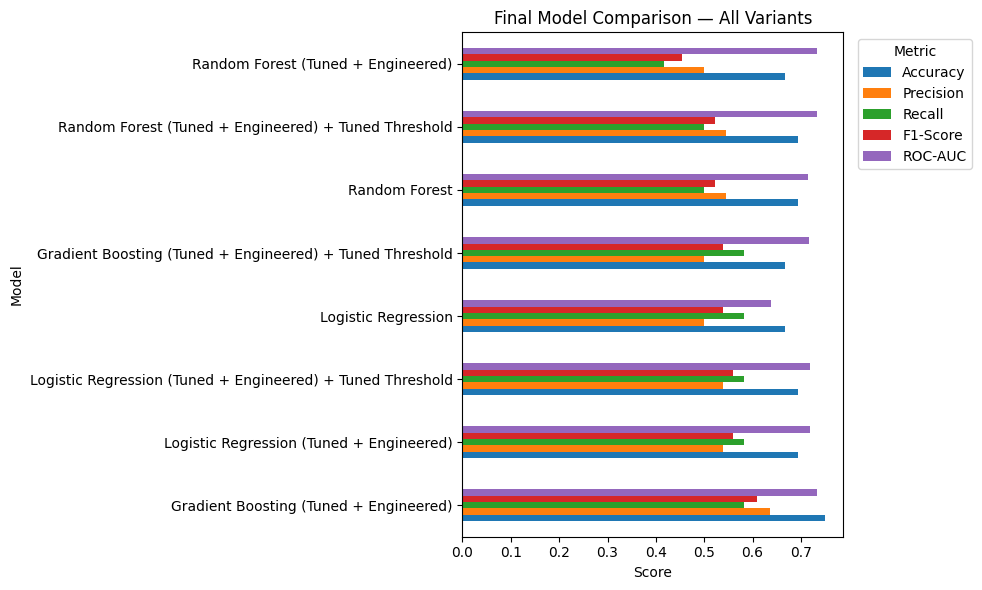

In [ ]:
final_comparison[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind="barh", figsize=(10, 6)
)
plt.title("Final Model Comparison — All Variants")
plt.xlabel("Score")
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### Final Interpretation and Recommendation

Considering every model variant evaluated — baseline, tuned, and threshold-tuned — the best final model by F1-score is:

**Gradient Boosting (Tuned + Engineered), at the default 0.50 threshold** — Accuracy **0.750**, Precision **0.636**, Recall **0.583**, F1-Score **0.609**, ROC-AUC **0.733**.

This is the strongest result across all eight variants tested. Interestingly, tuning its decision threshold on validation data did not improve this further — it actually lowered Gradient Boosting's F1 slightly to 0.538 on the test set, suggesting its default threshold already suited the test data well, and that the validation-chosen threshold did not transfer perfectly given the small sample size.

Logistic Regression is a close, simple runner-up (F1 0.560, whether tuned or not), and Random Forest ties for the best ROC-AUC (0.733) but trails on F1. The overall closeness of a simple linear model to two more complex ensembles reinforces that the relationship between playing-style statistics and winning is largely linear and additive, rather than driven by complex non-linear interactions.

This improves over the untuned baseline Logistic Regression (F1 0.538, ROC-AUC 0.639) and the untuned baseline Random Forest (F1 0.522, ROC-AUC 0.715). With only 88 matches and a 36-row test set, all these differences carry meaningful sampling uncertainty, and more completed matches would likely improve reliability more than further algorithmic tuning.

# Conclusion

This project tested whether team-level match statistics — possession, passing accuracy, attacking output, discipline, and defensive work rate — can predict whether a team wins a FIFA World Cup 2026 match. Using a dataset of 176 team-match records from 88 matches, the full data science workflow was applied: problem definition, data cleaning, exploratory data analysis, feature engineering, and the training, tuning, and evaluation of three classification algorithms — Logistic Regression, Random Forest, and Gradient Boosting.

**Key takeaways:**

- EDA showed interpretable signal in the data: winning teams generally had stronger possession, passing accuracy, attacking efficiency, and shot creation, while shots on target was the single strongest correlate of winning.
- A match-level (`match_id`) train/test split was used instead of a naive row-level split, to avoid leaking one team's match information into the evaluation of its opponent's row.
- The best-performing model overall was **Gradient Boosting (Tuned + Engineered)**, reaching a test-set F1-score of **0.609** and ROC-AUC of **0.733**, using its default classification threshold. Logistic Regression performed comparably as a simpler, fully interpretable alternative (F1 0.560), and Random Forest tied for the best ROC-AUC (0.733).
- The closeness of a simple linear model to two more complex ensemble models suggests the relationship between playing-style statistics and winning is largely linear and additive.
- Because the dataset contains only 88 matches, these results should be treated as an informative early read rather than a final, production-ready result. More completed matches would likely improve reliability more than further algorithms or tuning.
- This model is explanatory rather than predictive: every feature is measured during the match itself, so it describes what a winning performance looks like rather than forecasting a match that has not yet been played. A genuine forecast — for example, of tournament finishers — would require pre-match team ratings and a bracket simulation, which is a natural extension of this work.